In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.dates as mdates
from wordcloud import WordCloud
import spacy
import pandas as pd

In [2]:
# Load NLP model
nlp = spacy.load("en_core_web_sm")

#### __*If OSError:*__
[E050] Can't find model 'en_core_web_sm'. It doesn't seem to be a Python package or a valid path to a data directory.

#### __*Solution :*__ 
In your terminal run the following command
```shell
pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.7.0/en_core_web_sm-3.7.0-py3-none-any.whl#sha256=6215d71a3212690e9aec49408a27e3fe6ad7cd6c715476e93d70dc784041e93e
```

In [3]:
def extract_relevant_phrases(text):
    doc = nlp(text)
    relevant_phrases = []

    # Check for adjective phrases
    for token in doc:
        if token.pos_ == 'ADJ':
            subject = None
            for child in token.head.children:
                if child.dep_ in ['nsubj', 'nsubjpass'] and (
                        child.ent_type_ in ['ORG', 'MONEY', 'GPE'] or child.pos_ in ['PRON', 'NOUN']):
                    subject = child.text
                    break

            if subject:
                phrase = f"{subject} {token.text}"
                relevant_phrases.append(phrase)

    # If no adjective phrase found, check for single NER, ORG, or PRON led phrases
    if not relevant_phrases:
        for token in doc:
            if token.ent_type_ in ['ORG', 'MONEY', 'GPE'] or token.pos_ == 'PRON':
                closest_verb = None
                head = token.head
                while head.pos_ != 'VERB' and head.head != head:
                    head = head.head
                if head.pos_ == 'VERB':
                    closest_verb = head
                if closest_verb:
                    phrase = f"{token.text} {closest_verb.lemma_}"
                    relevant_phrases.append(phrase)
                    break  # Only consider the first relevant entity or pronoun

    return relevant_phrases

In [4]:
df=pd.read_csv('datasets/Preprocessed_csv.csv')
df.head()

,Date,clean_text,favorite_count,full_text,reply_count,retweet_count,entity_vectors,clean_text_vector,importance_coefficient,importance_coefficient_normalized,...,High,Low,Close,Adj Close,Volume,daily_return,historical_volatility,first_derivative,second_derivative,target
0,2021-02-01,sent givedirectly great work distributing fund...,3496.0,i sent some! https://t.co/mfyrz35zjf\r\n\r\nyo...,731.0,686,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[ 6.55804798e-02 -4.08827849e-02 5.29426113e-...,8043.5,0.013905,...,34638.21,32384.23,33537.18,33537.18,61400400660,0.01,0.00,0.00,0.00,1
1,2021-02-02,watch video learn truth doublespend separate f...,109.0,watch this video to learn the truth about what...,5.0,25,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[ 4.15213443e-02 -1.58386230e-02 -1.94963720e-...,245.5,0.000424,...,35896.88,33489.22,35510.29,35510.29,63088585433,0.06,0.02,1973.11,1973.11,1
2,2021-02-03,min video review strategy simple advanced help...,153.0,"in this 7min video, i review strategies from s...",9.0,24,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[-0.0159668 0.06502838 -0.05678711 0.042077...,334.5,0.000578,...,37480.19,35443.98,37472.09,37472.09,61166818159,0.06,0.02,0.00,0.00,1
3,2021-02-04,fair elon gave chance load bag early,196.0,to be fair elon gave all of you the chance to ...,31.0,18,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[ 9.04134139e-02 9.13085938e-02 1.20035803e-...,425.5,0.000736,...,38592.18,36317.50,36926.07,36926.07,68838074392,-0.01,0.03,0.00,0.00,0
4,2021-02-05,minute video ive learned much cant smash like ...,100.0,â30 minutes into the video and i've learned ...,7.0,8,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[ 0.02418934 0.05538386 -0.01659463 0.096178...,211.5,0.000366,...,38225.91,36658.76,38144.31,38144.31,58598066402,0.03,0.03,0.00,0.00,1


# Closing Price decreases fast

## From 2021-05-09 to 2021-05-28

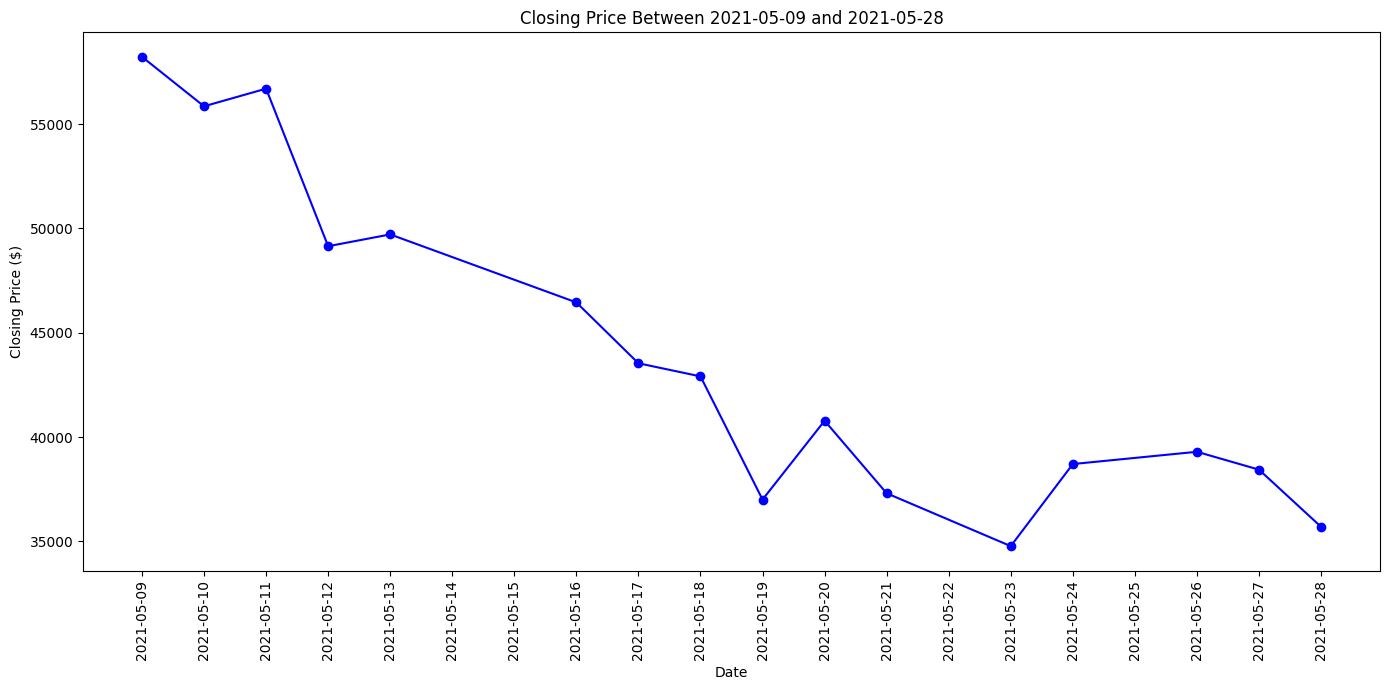

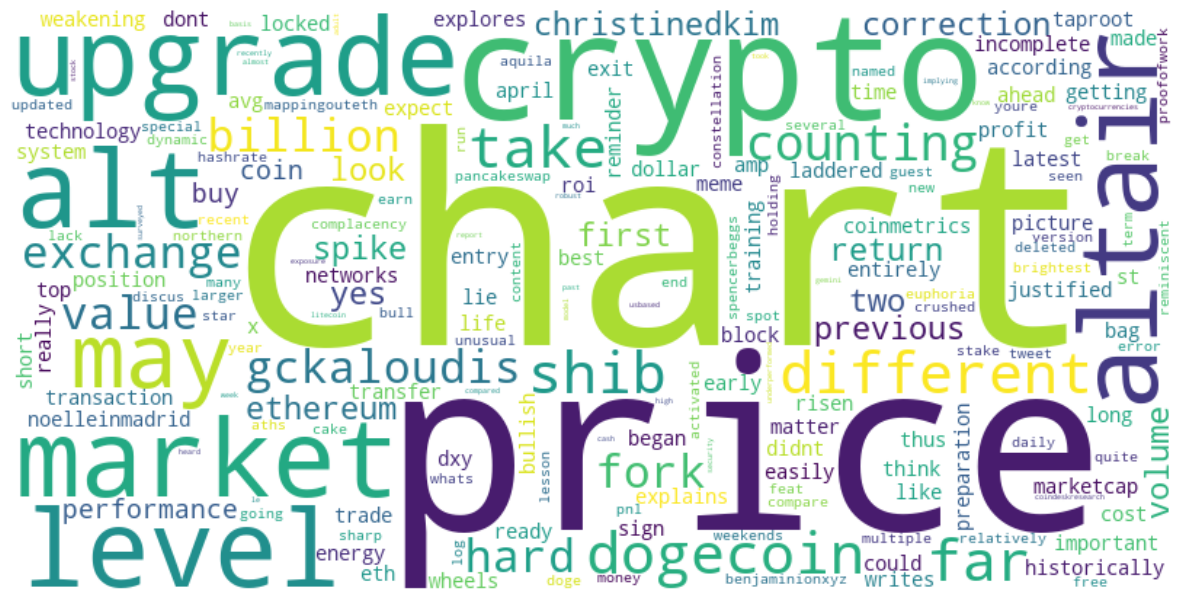

In [5]:

df = pd.read_csv('datasets/Preprocessed_csv.csv', index_col='clean_text', parse_dates=['Date'])

start_date = '2021-05-09'
end_date = '2021-05-28'
mask = (df['Date'] >= start_date) & (df['Date'] <= end_date)
filtered_df = df.loc[mask]

plt.figure(figsize=(14, 7))
plt.plot(filtered_df['Date'], filtered_df['Close'], marker='o', linestyle='-', color='blue')

plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=90)

plt.title(f'Closing Price Between {start_date} and {end_date}')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')

plt.tight_layout()
plt.show()

all_words = ' '.join(filtered_df.index.astype(str).tolist()).lower().split()
filtered_words = [word for word in all_words if word not in ['btc', 'bitcoin', 'bitcoins']]

word_counts = Counter(filtered_words)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Remove the axis
plt.show()


In [6]:
df = pd.read_csv('datasets/Preprocessed_csv.csv', parse_dates=['Date'])
keywords = ['altair', 'upgrade', 'chart', 'price', 'crypto', 'market', 'different', 'level']

keyword_mask = df['full_text'].apply(lambda text: any(keyword in text.lower() for keyword in keywords))
filtered_texts = df.loc[keyword_mask, ['full_text', 'favorite_count', 'reply_count', 'retweet_count',
                                       'importance_coefficient', 'sentiment_type']]

In [7]:
# Sort the filtered DataFrame by 'importance_coefficient' in descending order
sorted_texts = filtered_texts.sort_values(by='importance_coefficient', ascending=False)
sorted_texts.head(10)

,full_text,favorite_count,reply_count,retweet_count,importance_coefficient,sentiment_type
750,"given the changes in stable coins and banks, #...",28451.0,2677.0,6062,64302.5,1
371,rt @ukraine: stand with the people of ukraine....,0.0,0.0,53147,53147.0,1
747,"slept for 4 hours, woke up to:\r\n\r\nsilicon ...",21970.0,2408.0,3334,48478.0,-1
837,this is simply false. not sure if it's the jou...,21045.0,2927.0,4199,47752.5,1
455,i love seeing people with .eth in their handle...,20332.0,2204.0,2698,44464.0,1
645,i have spent hundreds of hours analyzing the m...,19375.0,2587.0,1708,41751.5,1
343,cryptorelief sending $100m of the $shiba funds...,16747.0,3105.0,3932,38978.5,1
256,not on holiday yet so i'll allow myself one mo...,16450.0,1180.0,4707,38197.0,-1
699,"i've been checking charts all this time, avoid...",16465.0,5388.0,1427,37051.0,-1
724,#bitcoin bull market .. so it begins https://t...,14329.0,767.0,2081,31122.5,0


In [8]:
sentiment_counts = sorted_texts['sentiment_type'].value_counts()
# Calculate average importance coefficient for each sentiment type
avg_importance_by_sentiment = sorted_texts.groupby('sentiment_type')['importance_coefficient'].mean()
print(sentiment_counts)
avg_importance_by_sentiment

sentiment_type
 1    137
 0     55
-1     52
Name: count, dtype: int64


sentiment_type
-1    9162.413462
 0    6347.863636
 1    6860.204380
Name: importance_coefficient, dtype: float64

### TOPIC OF THE NEGATIVE TEXTS


In [9]:
negative_texts = sorted_texts[sorted_texts['sentiment_type'] == -1]
texts = negative_texts['full_text'].reset_index().drop('index', axis=1)
texts['relevant_phrases'] = texts['full_text'].apply(extract_relevant_phrases)
texts[['full_text', 'relevant_phrases']]

,full_text,relevant_phrases
0,"slept for 4 hours, woke up to:\r\n\r\nsilicon ...",[]
1,not on holiday yet so i'll allow myself one mo...,[markets crazy]
2,"i've been checking charts all this time, avoid...",[i check]
3,"the longer the bear market rally, the more agg...",[]
4,reason why you are not buying btc below 30k no...,[you buy]
5,a friend told me what media is suppose to but ...,[me tell]
6,reason why you are not buying at this generati...,[reason same]
7,feels like we have hit max pain and uncertaint...,[we hit]
8,"i hate to admit it, but i also fell for the 10...",[i hate]
9,"one day you wake up and see #bitcoin at $21k, ...",[you wake]


Although during this period, the majority of tweets are in favor of bitcoin and that even the most important tweet has a positive sentiment score, after going into more details, we can see that on average, the negative tweets have a higher importance score than the positive and neutral ones. We can also see that consequently, the market is dropping. Why do the negative tweets have so much influence ? What is the topic of these tweets ? Who are the authors ? Based on the output above, the negative tweet with the highest importance score is report about a political socio-economical bad news towards Binance. As for the rest are tweets about how the market is going crazy and the threat of a huge drop because the bearishness of the market at that particular date. 

## Analysis of the day with the strongest closing price decrease

### Filter our data to get only days where the closing price decreased. We sort this new dataframe by decreasing magnitude of the closing price decrease

In [10]:
df['Date'] = pd.to_datetime(df['Date'])
df['daily_price_change'] = df['Close'].diff()
significant_drop_threshold = df['daily_price_change'].quantile(0.10)
significant_drop_dates = df[df['daily_price_change'] <= significant_drop_threshold]
drop_dates = significant_drop_dates[['Date', 'daily_price_change']]
sorted_drop_dates = drop_dates.sort_values(by='daily_price_change').reset_index(drop=True)
sorted_date_ranges = [(row['Date'] - pd.Timedelta(days=1), row['Date']) for index, row in sorted_drop_dates.iterrows()]

for start, end in sorted_date_ranges:
    print(f"{start.strftime('%Y-%m-%d')} to {end.strftime('%Y-%m-%d')}")

2021-05-11 to 2021-05-12
2021-05-18 to 2021-05-19
2021-09-06 to 2021-09-07
2021-02-22 to 2021-02-23
2021-04-17 to 2021-04-18
2021-09-19 to 2021-09-20
2021-12-03 to 2021-12-04
2022-06-12 to 2022-06-13
2022-01-20 to 2022-01-21
2021-06-20 to 2021-06-21
2021-10-20 to 2021-10-21
2022-05-08 to 2022-05-09
2021-11-25 to 2021-11-26
2021-05-20 to 2021-05-21
2021-11-17 to 2021-11-18
2022-02-16 to 2022-02-17
2021-11-15 to 2021-11-16
2021-03-14 to 2021-03-15
2021-12-12 to 2021-12-13
2021-02-21 to 2021-02-22
2022-03-03 to 2022-03-04
2021-05-15 to 2021-05-16
2022-05-04 to 2022-05-05
2021-12-27 to 2021-12-28
2022-02-20 to 2022-02-21
2021-06-24 to 2021-06-25
2021-03-21 to 2021-03-22
2021-05-16 to 2021-05-17
2021-12-02 to 2021-12-03
2021-12-08 to 2021-12-09
2021-05-27 to 2021-05-28
2022-04-10 to 2022-04-11
2021-10-25 to 2021-10-26
2022-11-08 to 2022-11-09
2021-02-24 to 2021-02-25
2021-04-20 to 2021-04-21
2022-03-09 to 2022-03-10
2021-05-22 to 2021-05-23
2021-11-21 to 2021-11-22
2021-07-07 to 2021-07-08


In [11]:
sorted_drop_dates

,Date,daily_price_change
0,2021-05-12,-7554.03
1,2021-05-19,-5906.96
2,2021-09-07,-5822.41
3,2021-02-23,-5382.89
4,2021-04-18,-4467.64
...,...,...
80,2021-11-04,-1517.82
81,2021-09-10,-1507.51
82,2022-03-03,-1472.33
83,2021-07-01,-1468.72


### The most significiant closing price decrease day was from 2021-05-11 to 2021-05-12


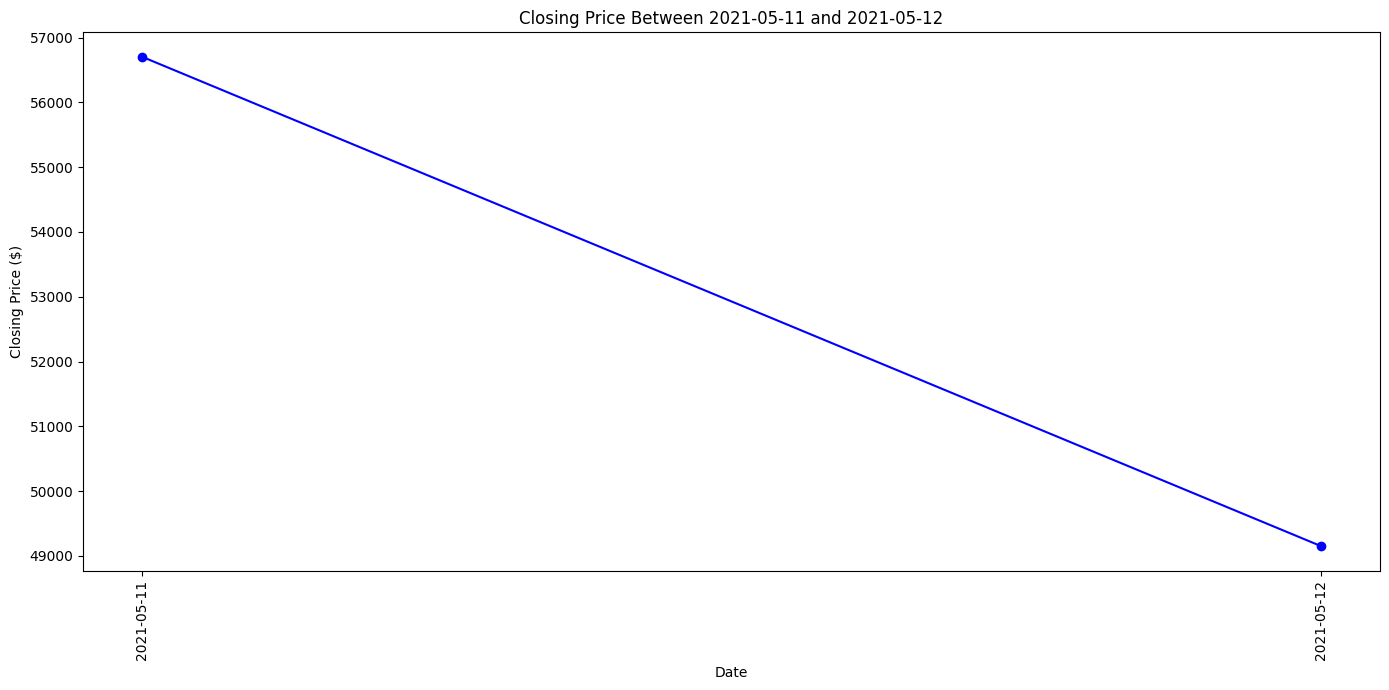

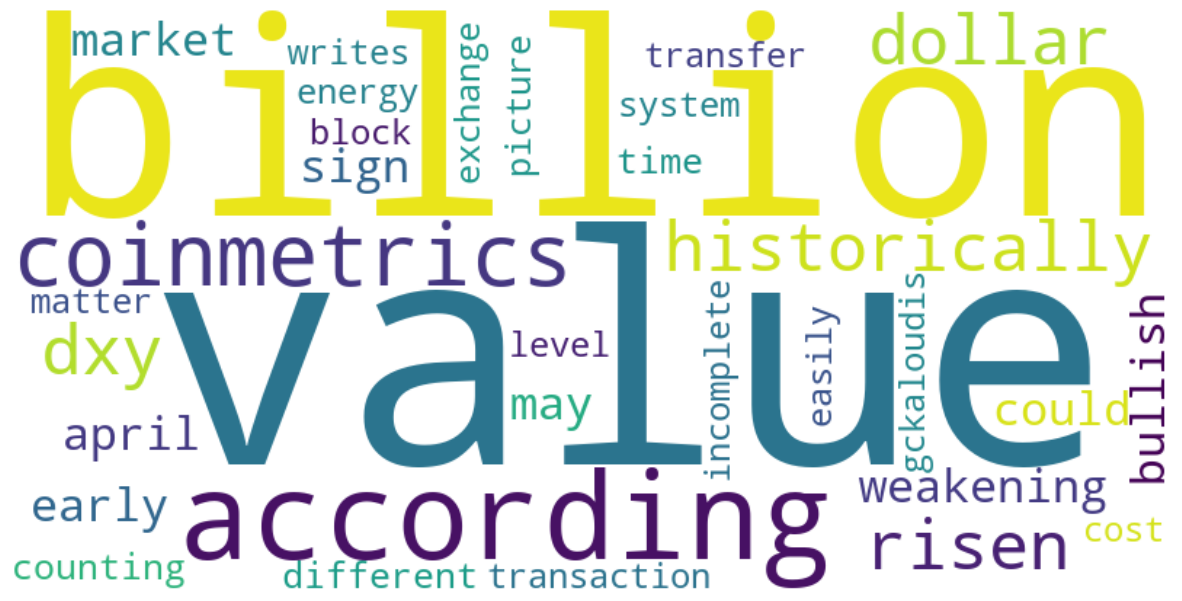

In [12]:
df = pd.read_csv('datasets/Preprocessed_csv.csv', index_col='clean_text', parse_dates=['Date'])
start_date = '2021-05-11'
end_date = '2021-05-12'
mask = (df['Date'] >= start_date) & (df['Date'] <= end_date)
filtered_df = df.loc[mask]
plt.figure(figsize=(14, 7))
plt.plot(filtered_df['Date'], filtered_df['Close'], marker='o', linestyle='-', color='blue')
plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=90)
plt.title(f'Closing Price Between {start_date} and {end_date}')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.tight_layout()
plt.show()

all_words = ' '.join(filtered_df.index.astype(str).tolist()).lower().split()
filtered_words = [word for word in all_words if word not in ['btc', 'bitcoin', 'bitcoins']]
word_counts = Counter(filtered_words)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Remove the axis
plt.show()


In [13]:
df = pd.read_csv('datasets/Preprocessed_csv.csv', parse_dates=['Date'])
keywords = ['value', 'billion', 'coinmetrics', 'bullish', 'historically', 'weakening']

keyword_mask = df['full_text'].apply(lambda text: any(keyword in text.lower() for keyword in keywords))
filtered_texts = df.loc[keyword_mask, ['full_text', 'favorite_count', 'reply_count', 'retweet_count',
                                       'importance_coefficient', 'sentiment_type']]
sorted_texts = filtered_texts.sort_values(by='importance_coefficient', ascending=False)
sorted_texts.head(10)

,full_text,favorite_count,reply_count,retweet_count,importance_coefficient,sentiment_type
750,"given the changes in stable coins and banks, #...",28451.0,2677.0,6062,64302.5,1
837,this is simply false. not sure if it's the jou...,21045.0,2927.0,4199,47752.5,1
714,a friend told me what media is suppose to but ...,12831.0,1850.0,2071,28658.0,-1
768,"just in: ðºð¸ us government to sell 41,500...",10447.0,2016.0,2433,24335.0,0
809,"a year ago today, ust/luna crashed. $40 billio...",10199.0,62.0,2000,22429.0,1
794,just in: ðºð¸ us senator ted cruz says he ...,9153.0,793.0,1863,20565.5,0
322,"i'm bearish on stocks, fixed income and real e...",9082.0,896.0,944,19556.0,-1
389,#btc is 60% below s2f model value. some think ...,8173.0,549.0,958,17578.5,-1
643,$btc\r\n\r\nno changes. it looks bearish. cons...,6384.0,794.0,669,13834.0,-1
316,"today, i would call bch mostly a failure. my m...",5812.0,518.0,788,12671.0,1


In [14]:
sentiment_counts = sorted_texts['sentiment_type'].value_counts()
avg_importance_by_sentiment = sorted_texts.groupby('sentiment_type')['importance_coefficient'].mean()
print(sentiment_counts)
avg_importance_by_sentiment

sentiment_type
 1    32
-1    12
 0     5
Name: count, dtype: int64


sentiment_type
-1     9224.750000
 0    11531.200000
 1     7744.421875
Name: importance_coefficient, dtype: float64

### TOPIC OF THE NEGATIVE TEXTS

In [15]:
negative_texts = sorted_texts[sorted_texts['sentiment_type'] == -1]

In [16]:
texts = negative_texts['full_text'].reset_index().drop('index', axis=1)

In [17]:
texts['relevant_phrases'] = texts['full_text'].apply(extract_relevant_phrases)
texts[['full_text', 'relevant_phrases']]

,full_text,relevant_phrases
0,a friend told me what media is suppose to but ...,[me tell]
1,"i'm bearish on stocks, fixed income and real e...","[i bearish, i bullish]"
2,#btc is 60% below s2f model value. some think ...,[some think]
3,$btc\r\n\r\nno changes. it looks bearish. cons...,"[it bearish, people bullish]"
4,more than 4 billion people are unbanked becaus...,[more unbanke]
5,na screw it im bullish now. make me my 7 milli...,[it screw]
6,"regarding $btc and the rest of the market, a q...","[pump likely, i bullish]"
7,iâll either look like a genius or an idiot i...,[i bullish]
8,the destruction of the turkish lira value is j...,[]
9,bitcoin attack: can bitcoin be taken down now ...,[just take]
